In [2]:
from MFDFA_functions import get_generalised_hurst, get_mf_spectrum
import numpy as np
import matplotlib.pyplot as plt
from MFDFA_new import MFDFA
from MFDFA_classes import MFDFA_Analysis_Empirical, MFDFA_Analysis_Empirical_D_only
import pandas as pd
from iaaft import surrogates
import datetime as dt
import pandas_datareader.data as web

In [2]:
def get_ticker_series(ticker, inv = False):

    start_lux = dt.datetime(2015, 6, 8)
    end_lux = dt.datetime(2025, 6, 6)
    
    df = web.DataReader(ticker, 'fred', start_lux, end_lux)

    if inv:
        df = 1 / df
    
    df.interpolate(inplace=True)
    
    df['Log_r'] = np.log(df[ticker]).diff()
    df.rename(columns={ticker: 'Mid'}, inplace =True)
    df.dropna(inplace=True)

    return df

In [32]:
ticker = 'DEXUSAL'

data = get_ticker_series(ticker)
data.to_parquet("DF_D_AUDUSD.parquet")

In [3]:
eurousd_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_EURUSD.parquet")
usdsgd_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_USDSGD.parquet")


usdjpy_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_USDJPY.parquet")

usdhkd_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_USDHKD.parquet")

In [ ]:
import yfinance as yf
import numpy as np

def get_usdtry_yahoo(start_date='2015-06-08', end_date='2025-06-07'):
    """
    Get USD/TRY daily spot prices from Yahoo Finance
    """
    # Download USD/TRY data
    ticker = 'TRY=X'  # Yahoo Finance symbol for USD/TRY
    
    try_usd = yf.download(ticker, start=start_date, end=end_date, progress=False)
    
    if try_usd.empty:
        print("No data found for USD/TRY")
        return None
    
    # Clean up the data
    df = try_usd[['Close']].copy()  # Use closing price as mid price
    df.rename(columns={'Close': 'Mid'}, inplace=True)
    
    # Remove any missing values by forward filling
    df.interpolate(inplace = True)
    df.dropna(inplace=True)
    
    # Calculate log returns
    df['Log_r'] = np.log(df['Mid']).diff()
    df.dropna(inplace=True)

    new_df = pd.DataFrame(index = df.index, columns=['Mid', 'Log_r'])
    new_df.index.name = "DATE"
    new_df['Mid'] = df['Mid']
    new_df['Log_r'] = df['Log_r']
    return new_df

# Get the data
usdtry_d = get_usdtry_yahoo()

# P-values

In [ ]:
datas = [eurousd_d, usdsgd_d, usdjpy_d, usdhkd_d]
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'daily_intraday_volatility']
names = ['EURUSD', 'USDSGD', 'USDJPY', 'USDHKD']

analyser = MFDFA_Analysis_Empirical_D_only(datas=datas,
                                    fraction_of_s5=2, # use np.inf to use all data
                                    s_min_d=10,
                                    s_min_s5=10,
                                    q_min=-10,
                                    q_max=10,
                                    m=1,
                                    steps=10,
                                    type=types[2],
                                    models=names,
                                    plots=True,
                                    end_trading_hr_euro=18,
                                    end_trading_hr_sgd=18,
                                    start_trading_hr_euro=6,
                                    start_trading_hr_sgd=2,
                                    unit_test=False, 
                                    shuffle=False, 
                                    compare_to_shuffle_ind=False, 
                                    n_surrogates=1000,
                                    accuracy_surrogates=5.0)

ps_abs_r, hursts_surr_abs_r, alphas_surr_abs_r, f_alphas_surr_abs_r, taos_surr_abs_r, df_surr_abs_r = analyser.surrogate_tests()

Generating surrogates for model EURUSD


Estim100%|██████████████████████████████| 1000/1000 [00:42<00:00, 23.48it/s]


Generating surrogates for model USDSGD


Estim100%|██████████████████████████████| 1000/1000 [01:09<00:00, 14.29it/s]


Generating surrogates for model AUDUSD


...

Estim100%|██████████████████████████████| 1000/1000 [01:26<00:00, 11.59it/s]


Generating surrogates for model USDJPY


Estim100%|██████████████████████████████| 1000/1000 [02:33<00:00,  6.51it/s]


Generating surrogates for model USDTWD


Estim100%|██████████████████████████████| 1000/1000 [03:08<00:00,  5.31it/s]


In [7]:
ps_abs_r

[array(0.47552448),
 array(0.19180819),
 array(0.83916084),
 array(0.71728272),
 array(0.95904096),
 array(0.00899101)]

In [8]:
np.savez("empirical_surrogate_tests_absolute_returns.npz", p_values=ps_abs_r)

In [9]:
np.savez("NEW_empirical_surrogate_data_abs_returns.npz", 
         EURUSD=df_surr_abs_r[0], 
         USDSGD=df_surr_abs_r[1], 
         AUDUSD=df_surr_abs_r[2], 
         USDCHF=df_surr_abs_r[3], 
         USDJPY=df_surr_abs_r[4], 
         USDTWD=df_surr_abs_r[5])

np.savez("NEW_empirical_surrogate_MF_abs_returns.npz", hursts=hursts_surr_abs_r, alphas=alphas_surr_abs_r, f_alphas=f_alphas_surr_abs_r, taos=taos_surr_abs_r)

Add on USDINR

In [72]:
datas = [usdtry_d]
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'daily_intraday_volatility']
names = ['USDINR']

analyser = MFDFA_Analysis_Empirical_D_only(datas=datas,
                                    fraction_of_s5=2, # use np.inf to use all data
                                    s_min_d=10,
                                    s_min_s5=10,
                                    q_min=-10,
                                    q_max=10,
                                    m=1,
                                    steps=10,
                                    type=types[2],
                                    models=names,
                                    plots=True,
                                    end_trading_hr_euro=18,
                                    end_trading_hr_sgd=18,
                                    start_trading_hr_euro=6,
                                    start_trading_hr_sgd=2,
                                    unit_test=False, 
                                    shuffle=False, 
                                    compare_to_shuffle_ind=False, 
                                    n_surrogates=100,
                                    accuracy_surrogates=5.0)

ps_abs_r, hursts_surr_abs_r, alphas_surr_abs_r, f_alphas_surr_abs_r, taos_surr_abs_r, df_surr_abs_r = analyser.surrogate_tests()

Generating surrogates for model USDINR


Estim100%|██████████████████████████████| 100/100 [00:23<00:00,  4.32it/s]



In [73]:
ps_abs_r

[array(0.00990099)]

For hong kong dollar above. 

# Spectrum

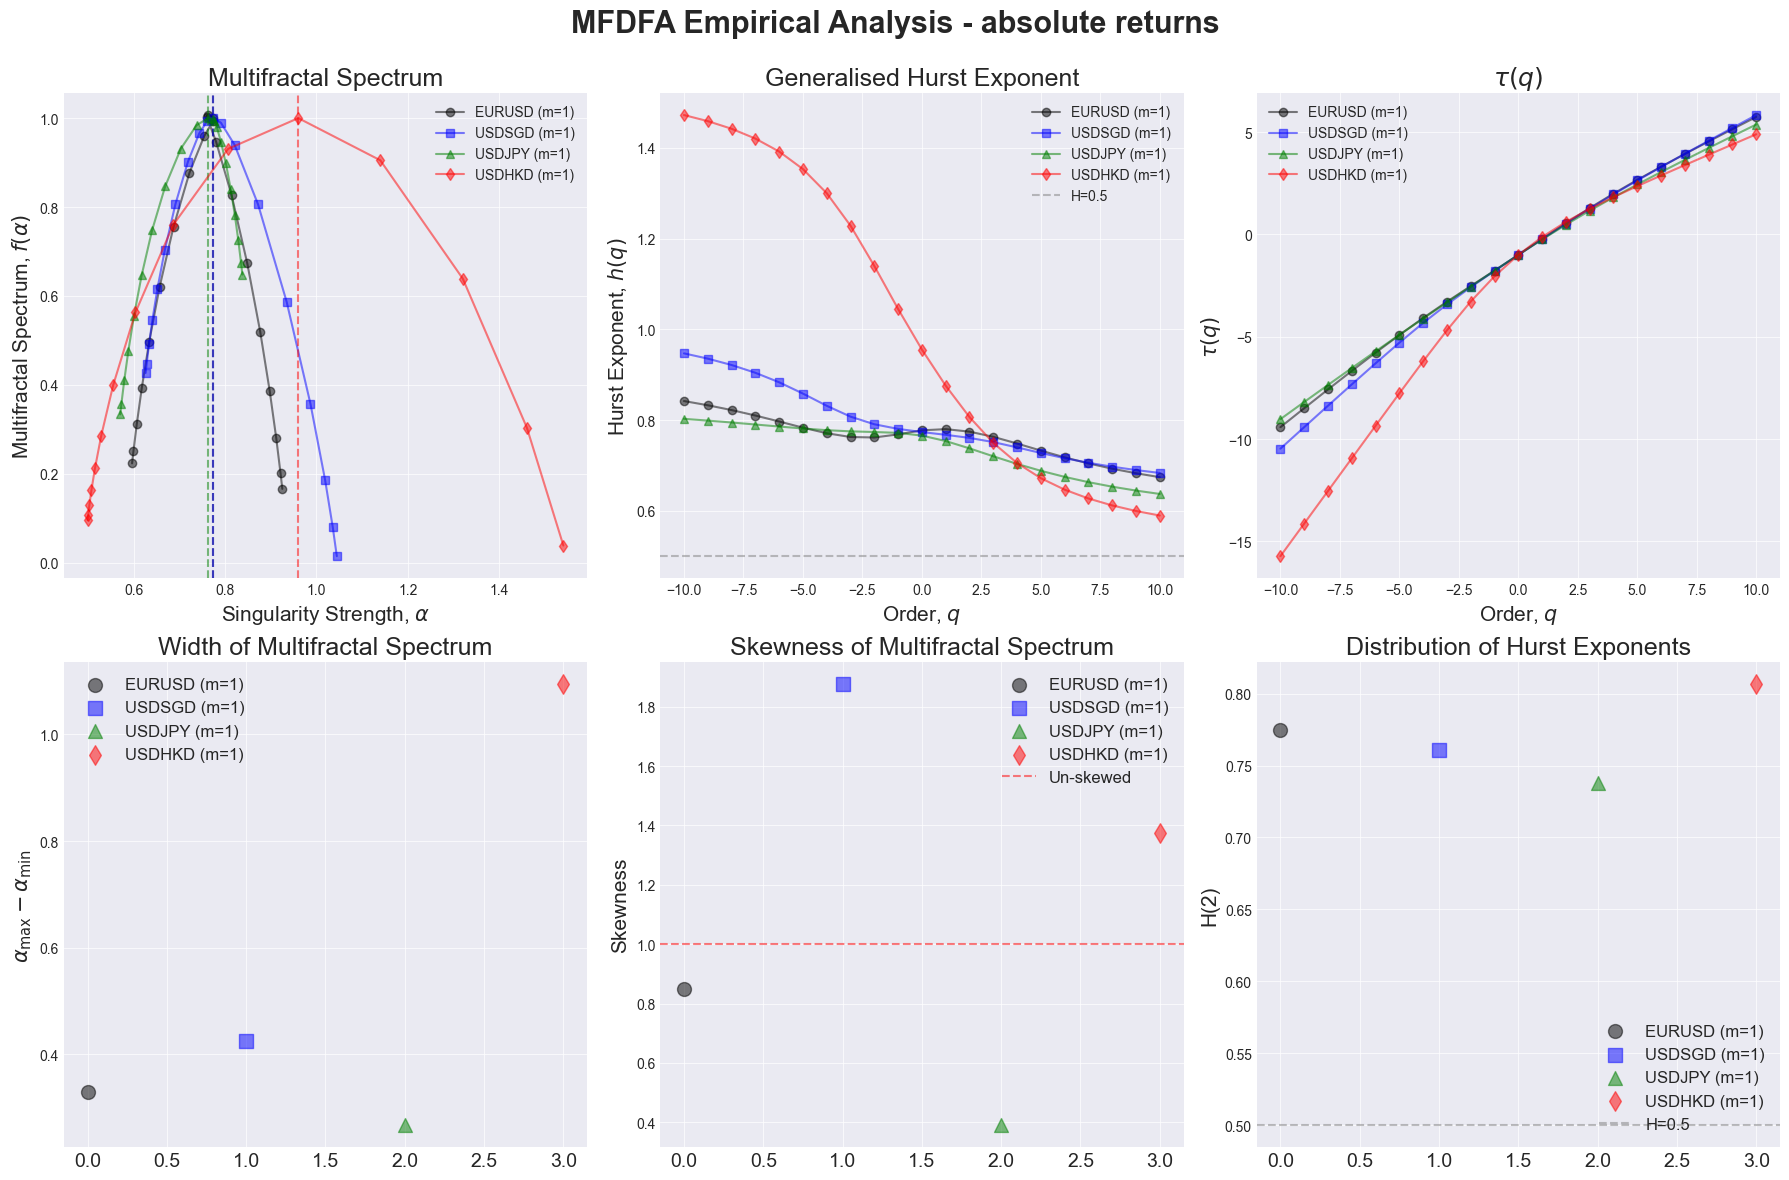

In [7]:
datas = [eurousd_d, usdsgd_d, usdjpy_d, usdhkd_d]
types = ['raw_log_returns', 'squared_returns', 'absolute returns', 'daily_intraday_volatility']
names = ['EURUSD (m=1)', 'USDSGD (m=1)', 'USDJPY (m=1)', 'USDHKD (m=1)']

ms = [1, 1, 1, 1]

analyser = MFDFA_Analysis_Empirical_D_only(datas=datas,
                                    fraction_of_s5=2, # use np.inf to use all data
                                    s_min_d=10,
                                    s_min_s5=10,
                                    q_min=-10,
                                    q_max=10,
                                    ms=ms,
                                    steps=10,
                                    type=types[2],
                                    models=names,
                                    plots=True,
                                    end_trading_hr_euro=18,
                                    end_trading_hr_sgd=18,
                                    start_trading_hr_euro=6,
                                    start_trading_hr_sgd=2,
                                    unit_test=False, 
                                    shuffle=False, 
                                    compare_to_shuffle_ind=False, 
                                    n_surrogates=1000,
                                    accuracy_surrogates=5.0)

analyser.get_plots()

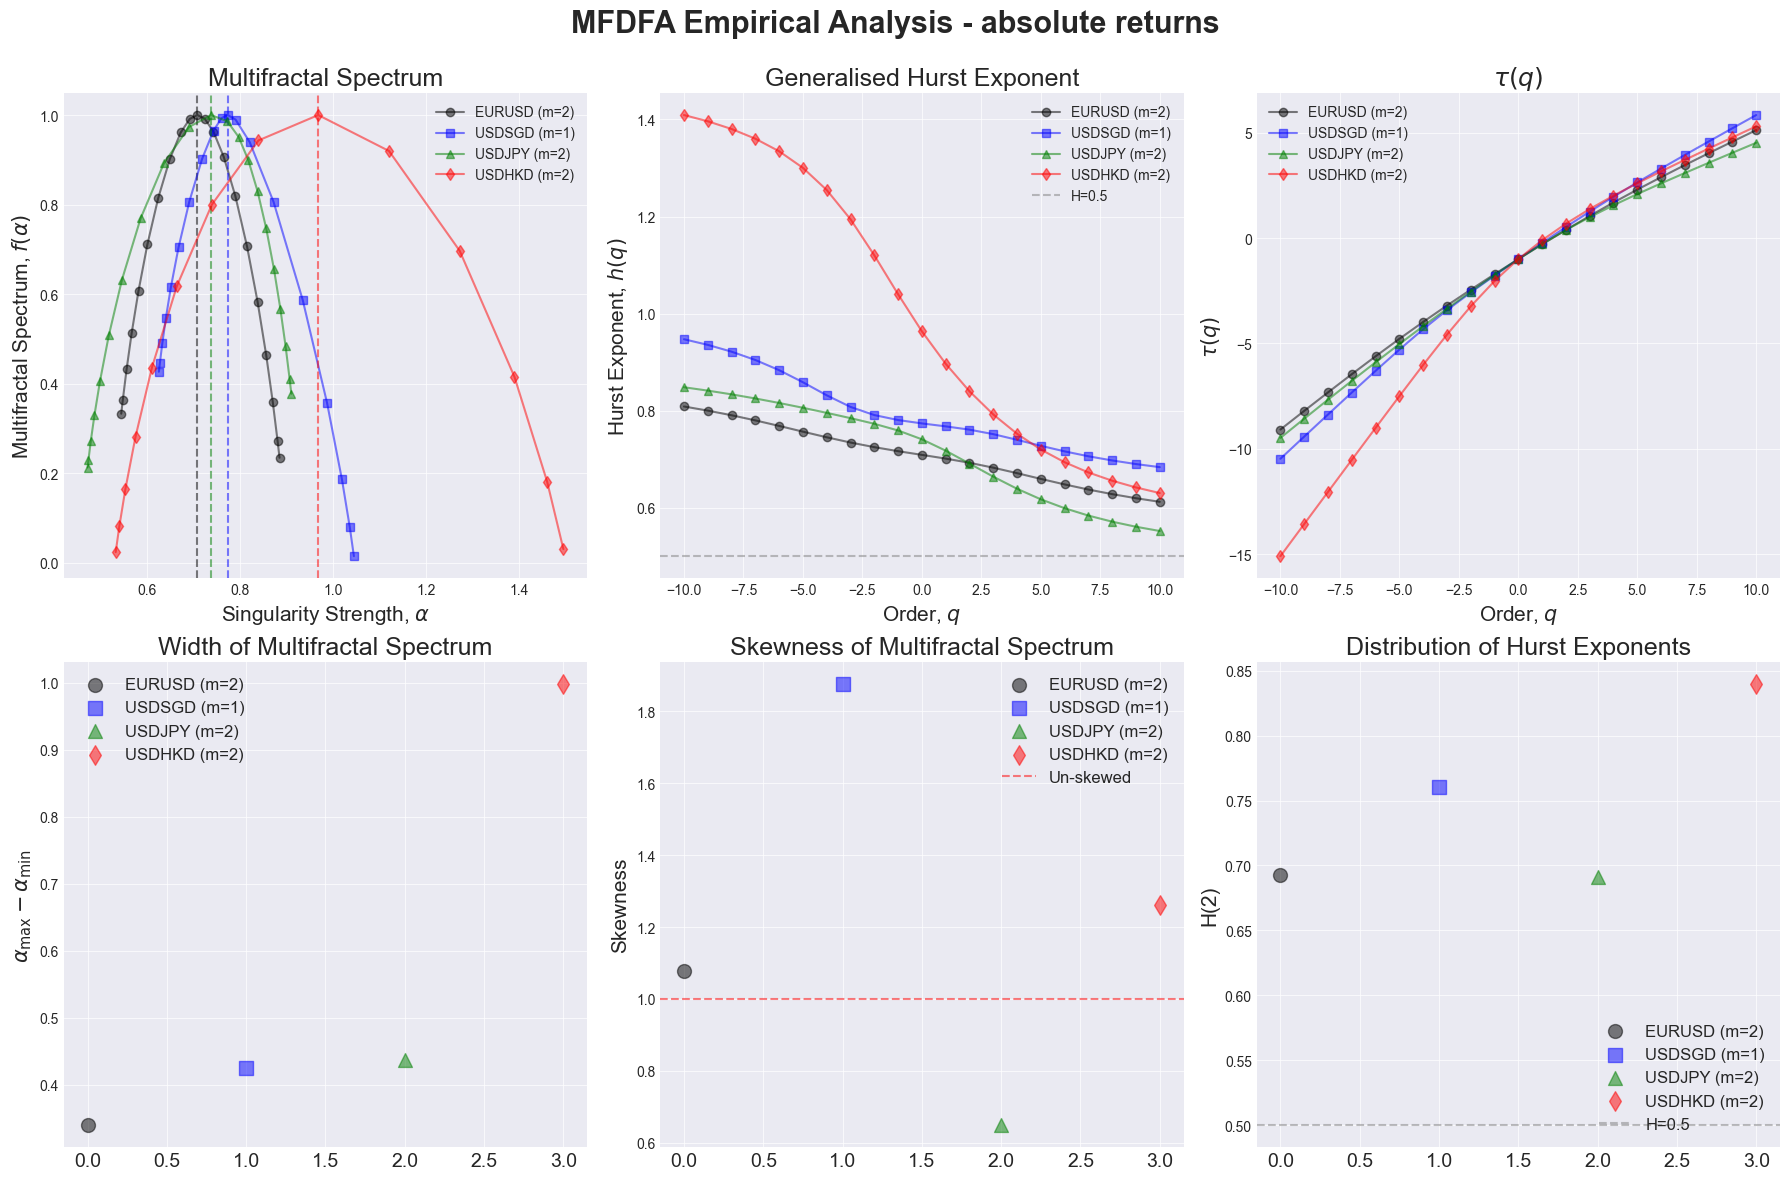

In [5]:
datas = [eurousd_d, usdsgd_d, usdjpy_d, usdhkd_d]
types = ['raw_log_returns', 'squared_returns', 'absolute returns', 'daily_intraday_volatility']
names = ['EURUSD (m=2)', 'USDSGD (m=1)', 'USDJPY (m=2)', 'USDHKD (m=2)']

ms = [2, 1, 2, 2]

analyser = MFDFA_Analysis_Empirical_D_only(datas=datas,
                                    fraction_of_s5=2, # use np.inf to use all data
                                    s_min_d=10,
                                    s_min_s5=10,
                                    q_min=-10,
                                    q_max=10,
                                    ms=ms,
                                    steps=10,
                                    type=types[2],
                                    models=names,
                                    plots=True,
                                    end_trading_hr_euro=18,
                                    end_trading_hr_sgd=18,
                                    start_trading_hr_euro=6,
                                    start_trading_hr_sgd=2,
                                    unit_test=False, 
                                    shuffle=False, 
                                    compare_to_shuffle_ind=False, 
                                    n_surrogates=1000,
                                    accuracy_surrogates=5.0)

analyser.get_plots()

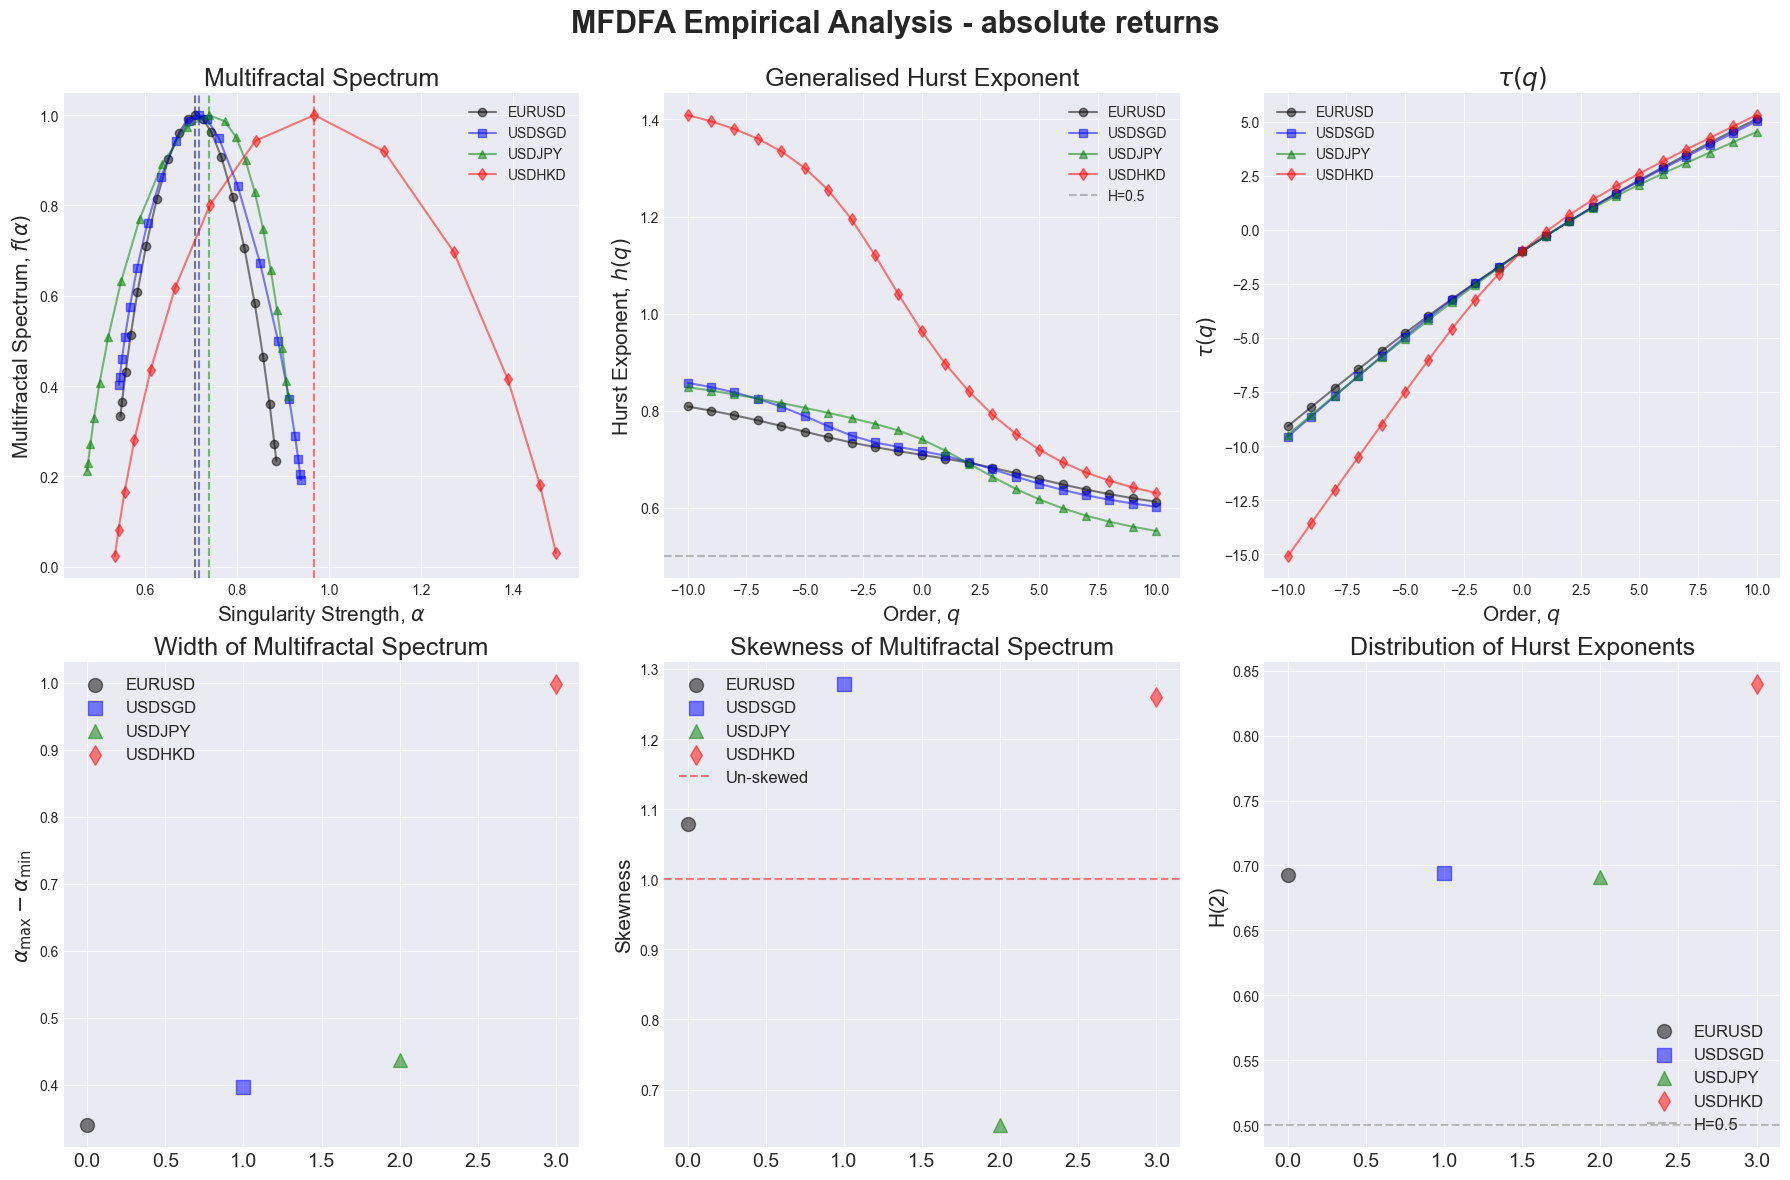

In [3]:
datas = [eurousd_d, usdsgd_d, usdjpy_d, usdhkd_d]
types = ['raw_log_returns', 'squared_returns', 'absolute returns', 'daily_intraday_volatility']
names = ['EURUSD', 'USDSGD', 'USDJPY', 'USDHKD']
ms2 = [2,2,2,2]
analyser = MFDFA_Analysis_Empirical_D_only(datas=datas,
                                    fraction_of_s5=2, # use np.inf to use all data
                                    s_min_d=10,
                                    s_min_s5=10,
                                    q_min=-10,
                                    q_max=10,
                                    ms=ms2,
                                    steps=10,
                                    type=types[2],
                                    models=names,
                                    plots=True,
                                    end_trading_hr_euro=18,
                                    end_trading_hr_sgd=18,
                                    start_trading_hr_euro=6,
                                    start_trading_hr_sgd=2,
                                    unit_test=False, 
                                    shuffle=False, 
                                    compare_to_shuffle_ind=False, 
                                    n_surrogates=1000,
                                    accuracy_surrogates=5.0)

analyser.get_plots()

/var/folders/ws/xbf0f9zj4qxc6drt1bjn4lg40000gn/T/ipykernel_10296/244447903.py:260: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  generalised_H[i] = get_generalised_hurst(F_q = F_qs[i], ss = segments)


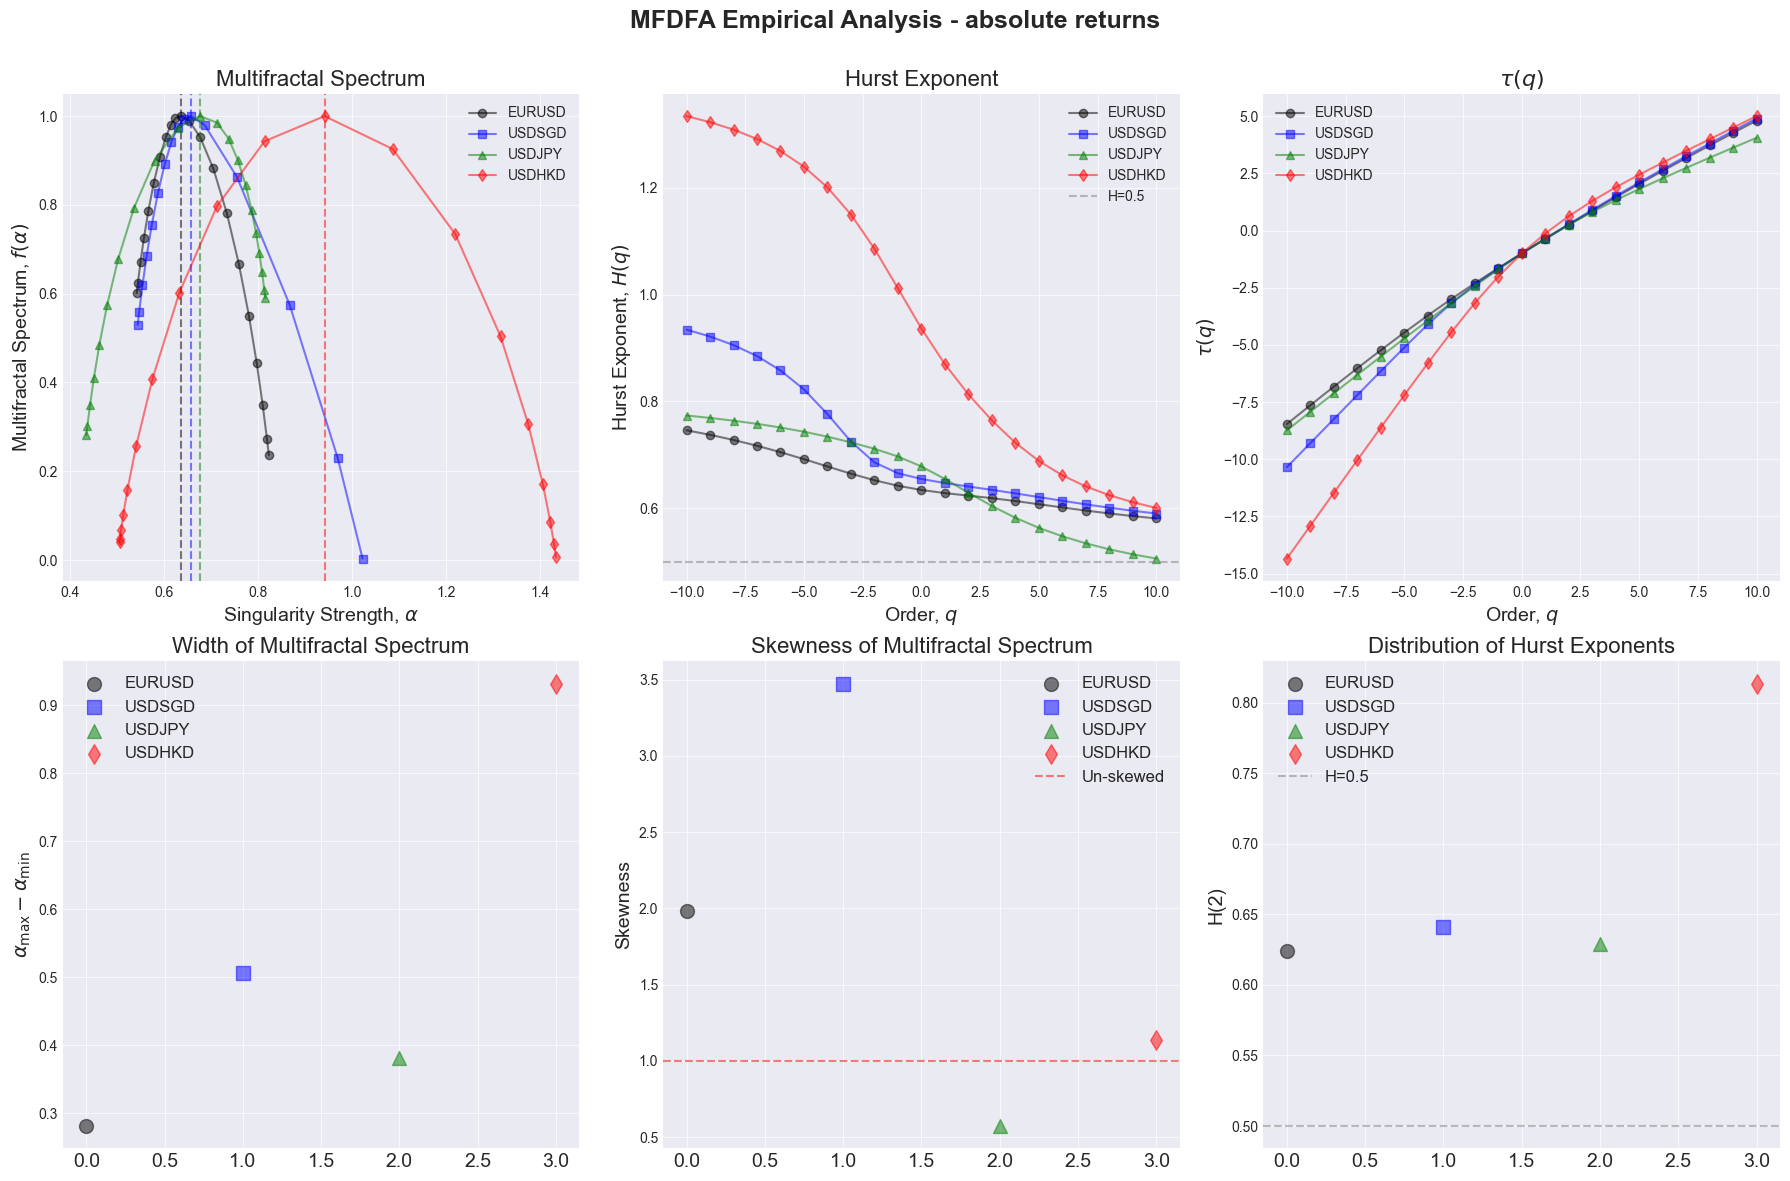

In [49]:
datas = [eurousd_d, usdsgd_d, usdjpy_d, usdhkd_d]
types = ['raw_log_returns', 'squared_returns', 'absolute returns', 'daily_intraday_volatility']
names = ['EURUSD', 'USDSGD', 'USDJPY', 'USDHKD']
m23 = [3,3,3,3]
analyser = MFDFA_Analysis_Empirical_D_only(datas=datas,
                                    fraction_of_s5=2, # use np.inf to use all data
                                    s_min_d=10,
                                    s_min_s5=10,
                                    q_min=-10,
                                    q_max=10,
                                    ms=m23,
                                    steps=10,
                                    type=types[2],
                                    models=names,
                                    plots=True,
                                    end_trading_hr_euro=18,
                                    end_trading_hr_sgd=18,
                                    start_trading_hr_euro=6,
                                    start_trading_hr_sgd=2,
                                    unit_test=False, 
                                    shuffle=False, 
                                    compare_to_shuffle_ind=False, 
                                    n_surrogates=1000,
                                    accuracy_surrogates=5.0)

analyser.get_plots()

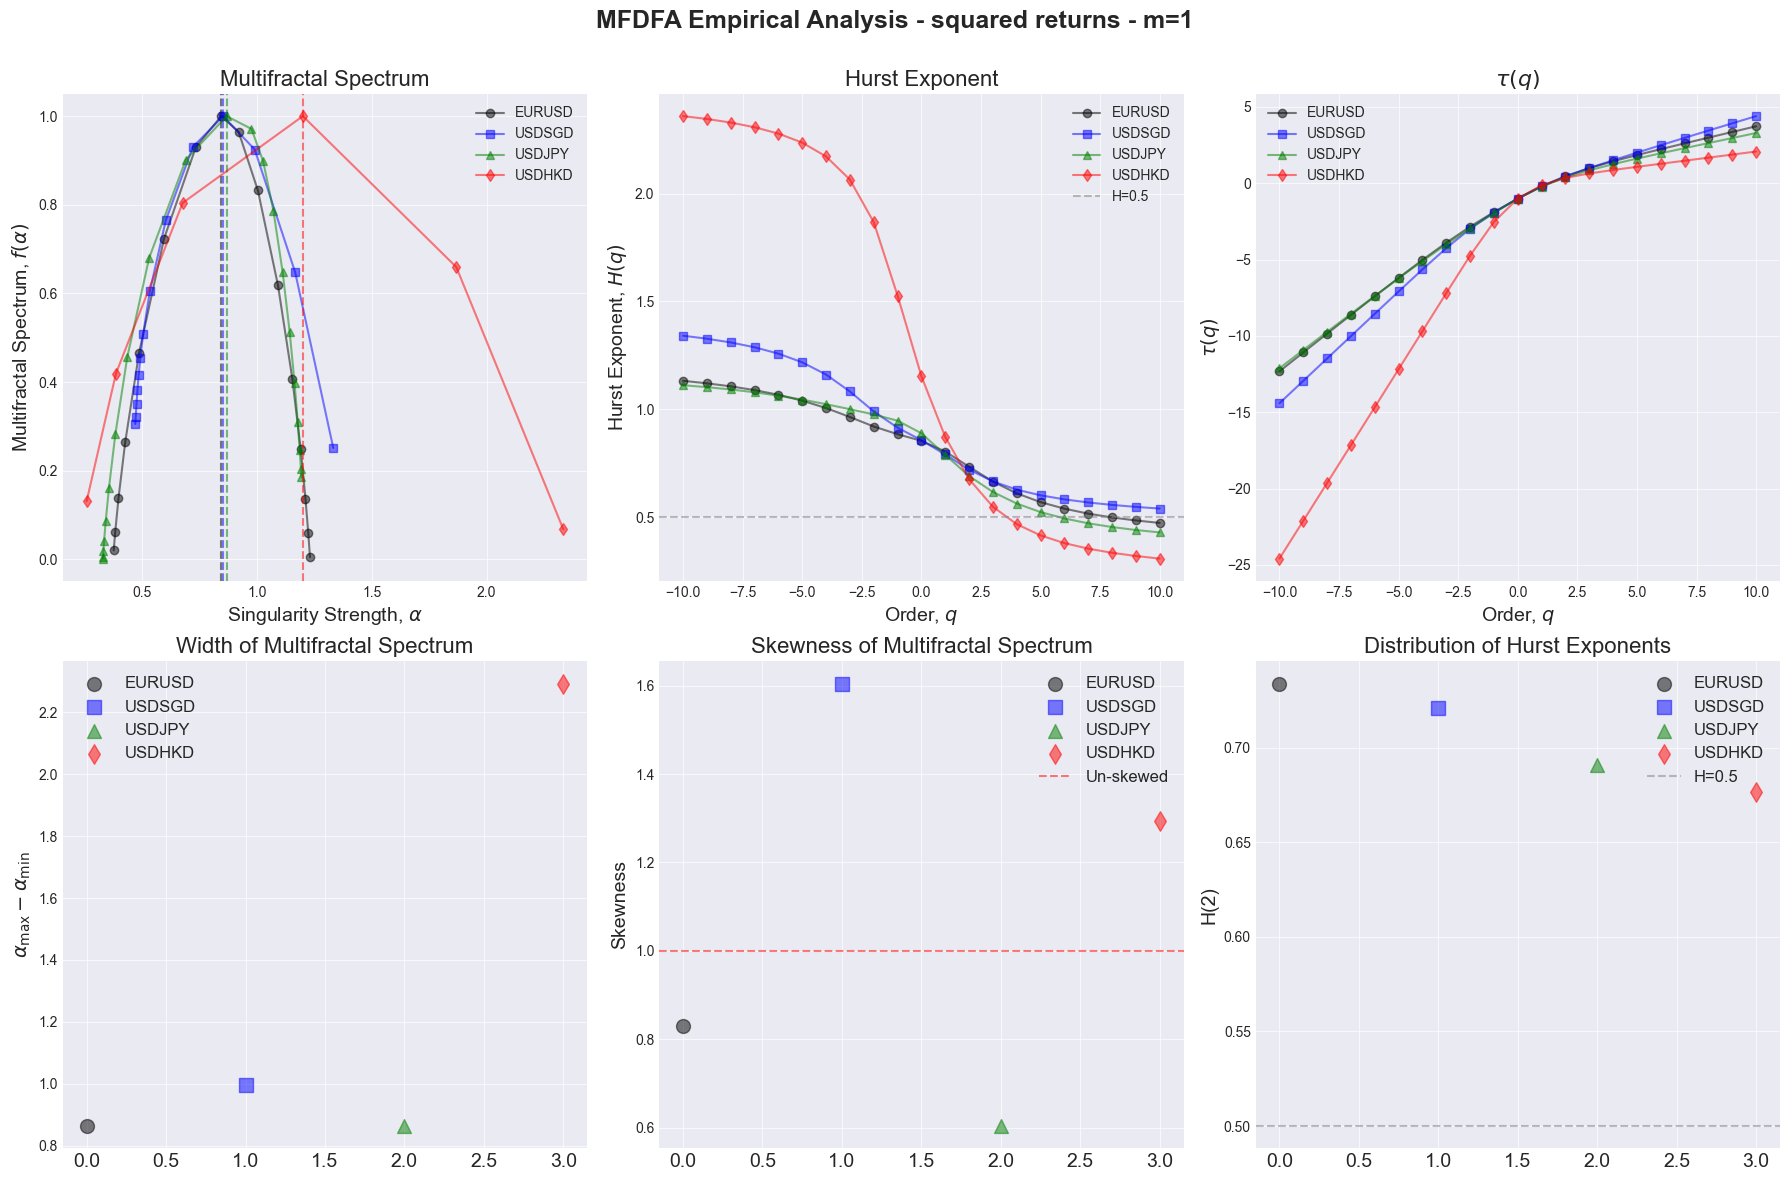

In [7]:
datas = [eurousd_d, usdsgd_d, usdjpy_d, usdhkd_d]
types = ['raw_log_returns', 'squared returns', 'absolute returns', 'daily_intraday_volatility']
names = ['EURUSD', 'USDSGD', 'USDJPY', 'USDHKD']

analyser = MFDFA_Analysis_Empirical_D_only(datas=datas,
                                    fraction_of_s5=2, # use np.inf to use all data
                                    s_min_d=10,
                                    s_min_s5=10,
                                    q_min=-10,
                                    q_max=10,
                                    m=1,
                                    steps=10,
                                    type=types[1],
                                    models=names,
                                    plots=True,
                                    end_trading_hr_euro=18,
                                    end_trading_hr_sgd=18,
                                    start_trading_hr_euro=6,
                                    start_trading_hr_sgd=2,
                                    unit_test=False, 
                                    shuffle=False, 
                                    compare_to_shuffle_ind=False, 
                                    n_surrogates=1000,
                                    accuracy_surrogates=5.0)

analyser.get_plots()

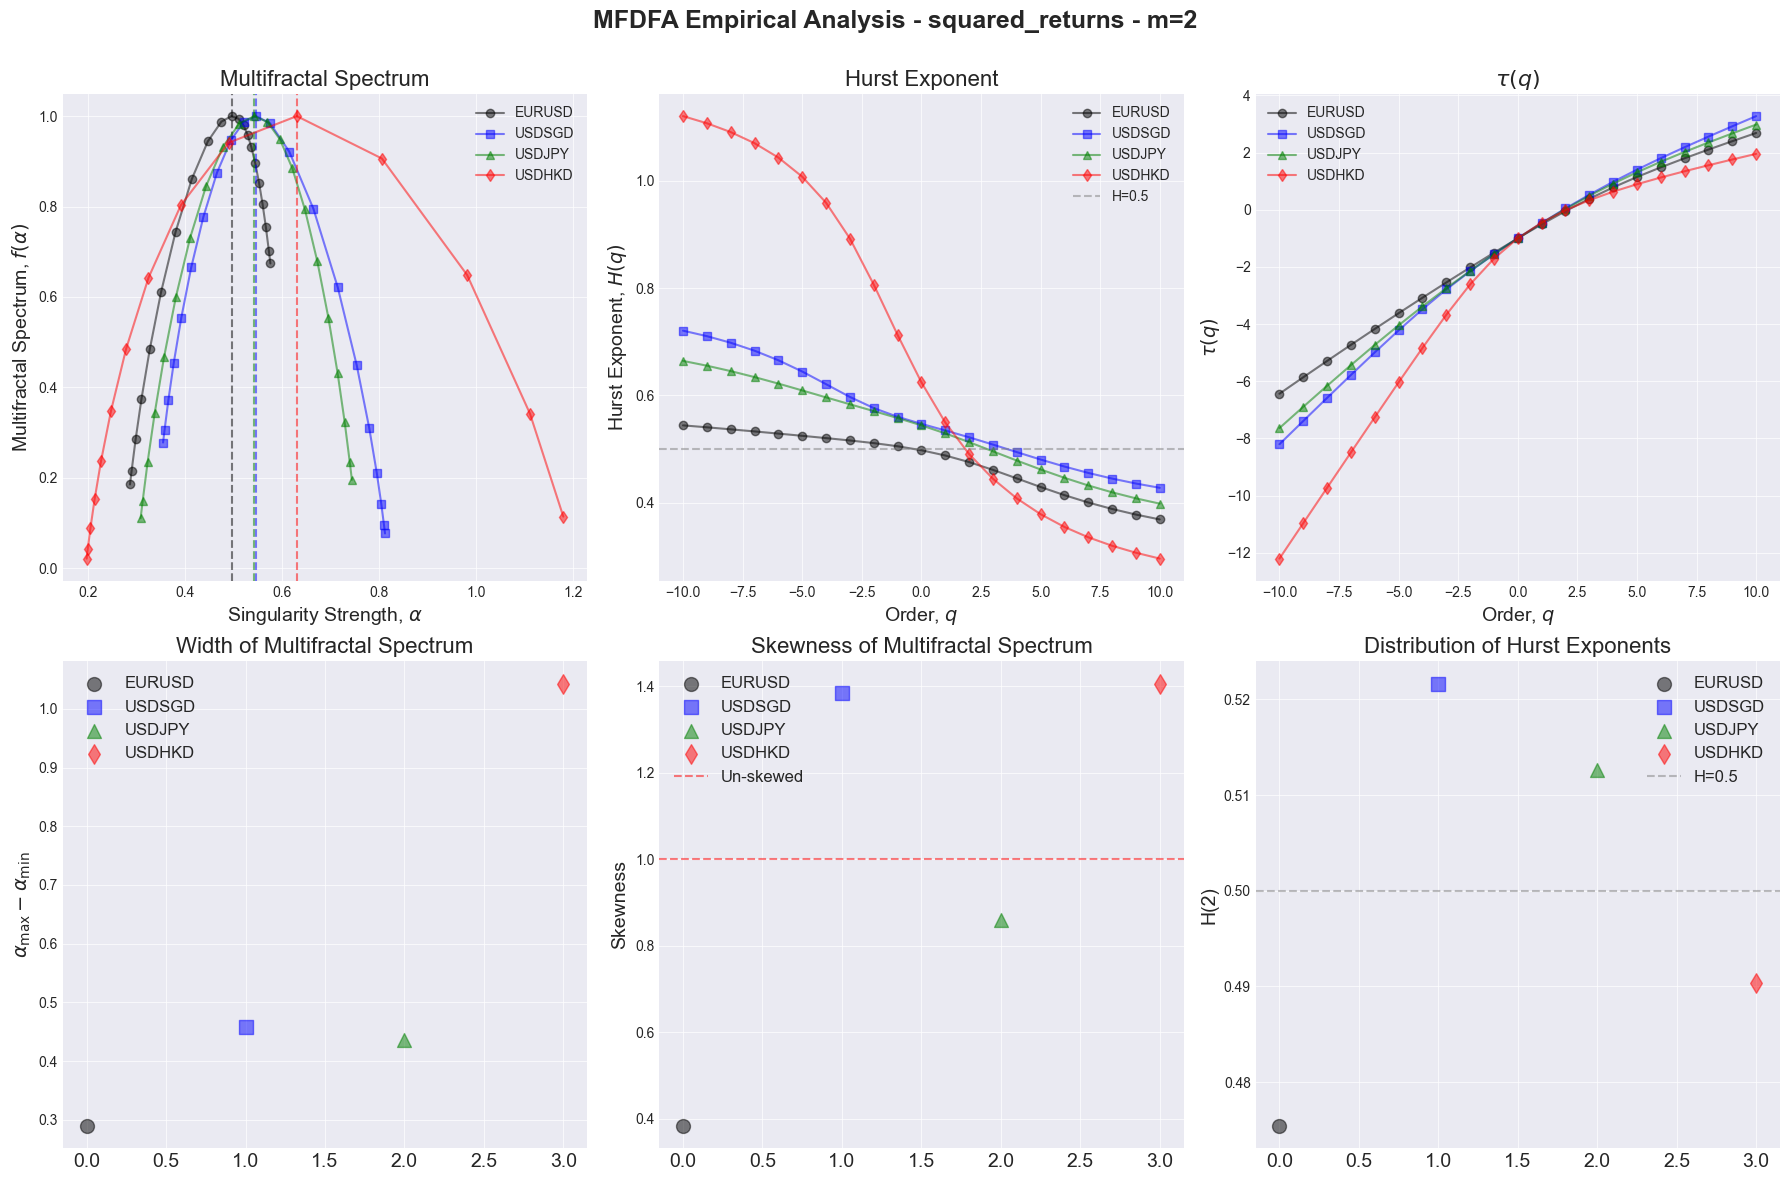

In [8]:
datas = [eurousd_d, usdsgd_d, usdjpy_d, usdhkd_d]
types = ['raw_log_returns', 'squared_returns', 'absolute returns', 'daily_intraday_volatility']
names = ['EURUSD', 'USDSGD', 'USDJPY', 'USDHKD']

analyser = MFDFA_Analysis_Empirical_D_only(datas=datas,
                                    fraction_of_s5=2, # use np.inf to use all data
                                    s_min_d=10,
                                    s_min_s5=10,
                                    q_min=-10,
                                    q_max=10,
                                    m=2,
                                    steps=10,
                                    type=types[1],
                                    models=names,
                                    plots=True,
                                    end_trading_hr_euro=18,
                                    end_trading_hr_sgd=18,
                                    start_trading_hr_euro=6,
                                    start_trading_hr_sgd=2,
                                    unit_test=False, 
                                    shuffle=False, 
                                    compare_to_shuffle_ind=False, 
                                    n_surrogates=1000,
                                    accuracy_surrogates=5.0)

analyser.get_plots()

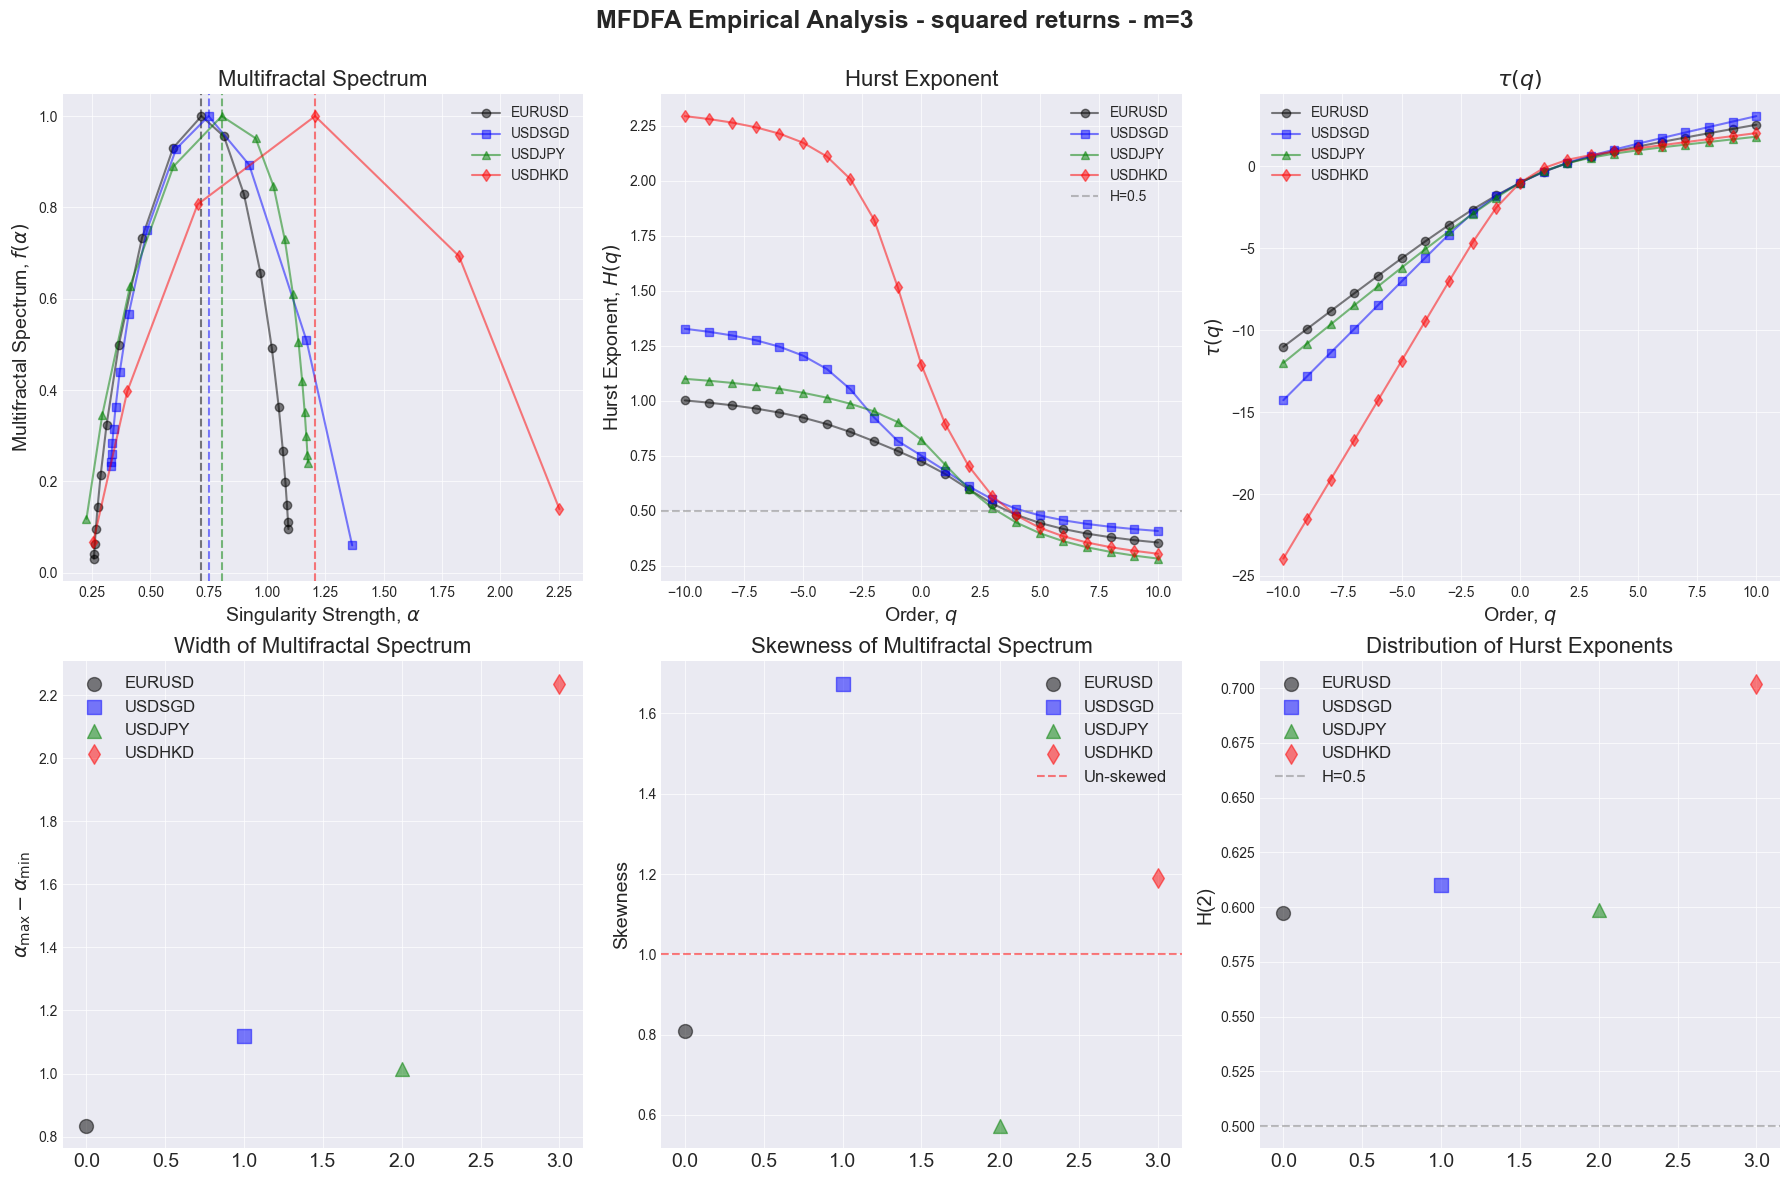

In [9]:
datas = [eurousd_d, usdsgd_d, usdjpy_d, usdhkd_d]
types = ['raw_log_returns', 'squared returns', 'absolute returns', 'daily_intraday_volatility']
names = ['EURUSD', 'USDSGD', 'USDJPY', 'USDHKD']

analyser = MFDFA_Analysis_Empirical_D_only(datas=datas,
                                    fraction_of_s5=2, # use np.inf to use all data
                                    s_min_d=10,
                                    s_min_s5=10,
                                    q_min=-10,
                                    q_max=10,
                                    m=3,
                                    steps=10,
                                    type=types[1],
                                    models=names,
                                    plots=True,
                                    end_trading_hr_euro=18,
                                    end_trading_hr_sgd=18,
                                    start_trading_hr_euro=6,
                                    start_trading_hr_sgd=2,
                                    unit_test=False, 
                                    shuffle=False, 
                                    compare_to_shuffle_ind=False, 
                                    n_surrogates=1000,
                                    accuracy_surrogates=5.0)

analyser.get_plots()